In [1]:
from pathlib import Path
import sys
import numpy as np

PROJECT_ROOT = Path("..").resolve()
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from IPython.display import Audio


In [2]:
from spectral_mixture_analysis.audio import load_mono_audio, match_length, mix_signals
from spectral_mixture_analysis.transforms import (
    compute_stft_complex,
    magnitude_spectrogram,
    amplitude_to_db,
)
from spectral_mixture_analysis.metrics import l2_error, relative_l2_error
from spectral_mixture_analysis.plotting import plot_spectrogram, plot_difference_map

In [27]:
audio_path_1 = PROJECT_ROOT / "data" / "samples" / "Track1_flute.wav"
audio_path_2 = PROJECT_ROOT / "data" / "samples" / "Track10_Bass.wav"
x, sr = load_mono_audio(audio_path_1, sr=22050)
y, _ = load_mono_audio(audio_path_2, sr=22050)

x, y = match_length(x, y, mode="truncate")
mix = x + y

In [37]:
from spectral_mixture_analysis.dataset import build_sample_index

samples_root = PROJECT_ROOT / "data" / "samples"
index_df = build_sample_index(samples_root)

index_df.head(12)

,instrument,track_id,path,filename
0,bass,1,/home/satan/git/spectrogram-analysis/data/samp...,Track1_Bass.wav
1,flute,1,/home/satan/git/spectrogram-analysis/data/samp...,Track1_flute.wav
2,piano,1,/home/satan/git/spectrogram-analysis/data/samp...,Track1_Acoustic_Grand_Piano.wav
3,trumpet,1,/home/satan/git/spectrogram-analysis/data/samp...,Track1_trumpet.wav
4,bass,2,/home/satan/git/spectrogram-analysis/data/samp...,Track2_Bass.wav
5,flute,2,/home/satan/git/spectrogram-analysis/data/samp...,Track2_flute.wav
6,piano,2,/home/satan/git/spectrogram-analysis/data/samp...,Track2_Acoustic_Grand_Piano.wav
7,trumpet,2,/home/satan/git/spectrogram-analysis/data/samp...,Track2_trumpet.wav
8,bass,3,/home/satan/git/spectrogram-analysis/data/samp...,Track3_Bass.wav
9,flute,3,/home/satan/git/spectrogram-analysis/data/samp...,Track3_flute.wav


In [39]:
from spectral_mixture_analysis.dataset import get_track_instrument_pairs, get_same_pair_across_tracks

pairs_track_1 = get_track_instrument_pairs(index_df, track_id=1)
pairs_bass_flute = get_same_pair_across_tracks(index_df, "bass", "flute")

In [28]:

print("Audio x")
display(Audio(x, rate=sr))

print("Audio y")
display(Audio(y, rate=sr))

print("Mixture x+y")
mix_listen = mix / (np.max(np.abs(mix)) + 1e-9)
display(Audio(mix_listen, rate=sr))

Audio x


Audio y


Mixture x+y


In [29]:
N_FFT = 2048
HOP = 512

X = compute_stft_complex(x, n_fft=N_FFT, hop_length=HOP)
Y = compute_stft_complex(y, n_fft=N_FFT, hop_length=HOP)
M = compute_stft_complex(mix, n_fft=N_FFT, hop_length=HOP)

mag_x = magnitude_spectrogram(X)
mag_y = magnitude_spectrogram(Y)
mag_mix = magnitude_spectrogram(M)
mag_sum = mag_x + mag_y

mix_db = amplitude_to_db(mag_mix)
sum_db = amplitude_to_db(mag_sum)
diff = mag_mix - mag_sum

In [30]:
overlap = np.sum(np.minimum(mag_x, mag_y)) / np.sum(mag_x + mag_y)
overlap_db = amplitude_to_db(np.array([overlap]), ref=1.0)[0]
print(f"Overlap: {overlap:.4f} ({overlap_db:.2f} dB)")

Overlap: 0.0187 (-34.57 dB)


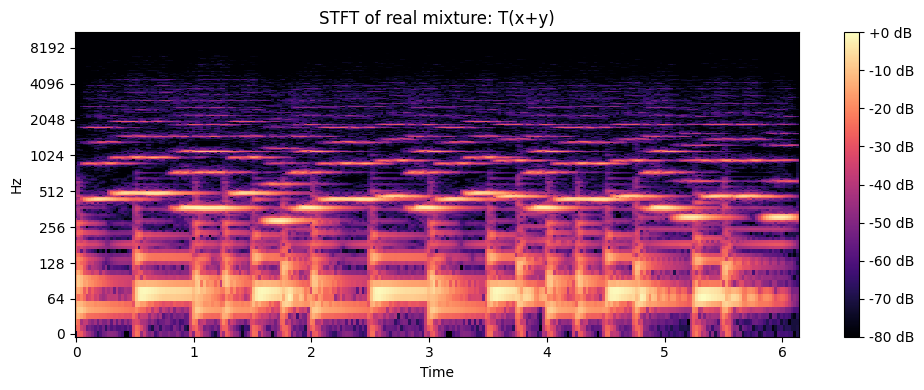

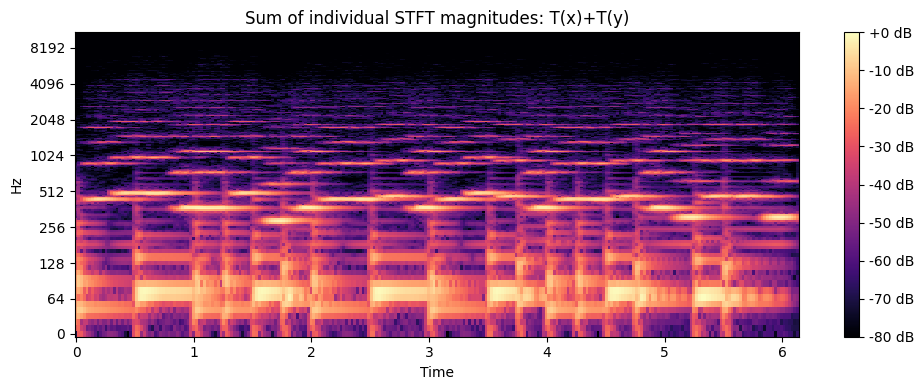

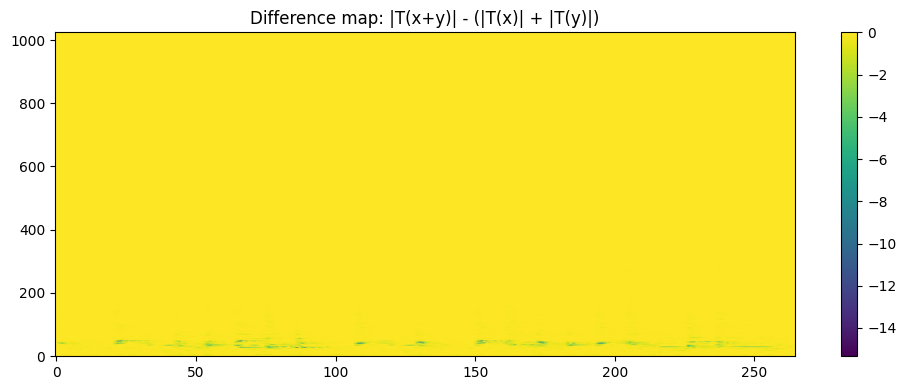

In [31]:
plot_spectrogram(mix_db, sr=sr, hop_length=HOP, title="STFT of real mixture: T(x+y)")
plot_spectrogram(sum_db, sr=sr, hop_length=HOP, title="Sum of individual STFT magnitudes: T(x)+T(y)")
plot_difference_map(diff, title="Difference map: |T(x+y)| - (|T(x)| + |T(y)|)")

In [32]:
from spectral_mixture_analysis.analysis import evaluate_mixture_linearity_stft

metrics = evaluate_mixture_linearity_stft(x, y)

print(metrics)

{'l2': 95.8992691040039, 'relative_l2': 0.0169327761977911, 'mae': 0.019263537600636482}


In [33]:
from spectral_mixture_analysis.analysis import evaluate_dataset_pairs

pairs = [
    (PROJECT_ROOT / "data" / "raw" / "audio01_bass.wav",
     PROJECT_ROOT / "data" / "raw" / "audio02_vocal.wav"),

    (PROJECT_ROOT / "data" / "raw" / "audio03_bass.wav",
     PROJECT_ROOT / "data" / "raw" / "audio04_flute.wav"),

    (PROJECT_ROOT / "data" / "raw" / "audio05_guitar_aco.wav",
     PROJECT_ROOT / "data" / "raw" / "audio06_guitar_ele.wav"),

    (PROJECT_ROOT / "data" / "raw" / "audio07_keyboard_aco.wav",
     PROJECT_ROOT / "data" / "raw" / "audio08_keyboard_ele.wav"),

    (PROJECT_ROOT / "data" / "raw" / "audio09_keyboard_ele.wav",
     PROJECT_ROOT / "data" / "raw" / "audio10_organ_ele.wav"),
     
    (PROJECT_ROOT / "data" / "samples" / "Track1_flute.wav",
     PROJECT_ROOT / "data" / "samples" / "Track10_Bass.wav")
]

df = evaluate_dataset_pairs(pairs)

df

,file_x,file_y,l2,relative_l2,mae
0,audio01_bass,audio02_vocal,506.381989,0.143900,0.039424
1,audio03_bass,audio04_flute,98.245613,0.021941,0.048399
2,audio05_guitar_aco,audio06_guitar_ele,169.174225,0.059320,0.016000
3,audio07_keyboard_aco,audio08_keyboard_ele,279.219238,0.108074,0.029312
4,audio09_keyboard_ele,audio10_organ_ele,726.214905,0.139273,0.116056
5,Track1_flute,Track10_Bass,95.899269,0.016933,0.019264


In [40]:
from spectral_mixture_analysis.analysis import evaluate_dataset_pairs

pairs_bass_flute = get_same_pair_across_tracks(index_df, "bass", "flute")
df_bass_flute = evaluate_dataset_pairs(pairs_bass_flute)

df_bass_flute

,file_x,file_y,l2,relative_l2,mae
0,Track1_Bass,Track1_flute,126.191376,0.023020,0.026320
1,Track2_Bass,Track2_flute,36.859509,0.006579,0.011738
2,Track3_Bass,Track3_flute,18.992817,0.003815,0.007996
3,Track4_Bass,Track4_flute,38.776031,0.007595,0.018238
4,Track5_Bass,Track5_flute,43.084862,0.007491,0.017093
5,Track6_Bass,Track6_flute,56.582256,0.009675,0.019462
6,Track7_Bass,Track7_flute,43.543262,0.006531,0.014011
7,Track8_Bass,Track8_flute,78.766548,0.012872,0.018497
8,Track9_Bass,Track9_flute,171.688034,0.035505,0.035242
9,Track10_Bass,Track10_flute,84.274147,0.013106,0.018009


In [41]:
pairs_track_1 = get_track_instrument_pairs(index_df, track_id=1)
df_track_1 = evaluate_dataset_pairs(pairs_track_1)

df_track_1

,file_x,file_y,l2,relative_l2,mae
0,Track1_Bass,Track1_flute,126.191376,0.023020,0.026320
1,Track1_Bass,Track1_Acoustic_Grand_Piano,528.078735,0.101309,0.101649
2,Track1_Bass,Track1_trumpet,141.039978,0.026973,0.025405
3,Track1_flute,Track1_Acoustic_Grand_Piano,1033.412354,0.187669,0.137237
4,Track1_flute,Track1_trumpet,1170.415161,0.215639,0.230779
5,Track1_Acoustic_Grand_Piano,Track1_trumpet,590.202820,0.112095,0.144737


In [42]:
from spectral_mixture_analysis.analysis import evaluate_dataset_pairs

pairs_piano_trumpet = get_same_pair_across_tracks(index_df, "piano", "trumpet")
df_piano_trumpet = evaluate_dataset_pairs(pairs_piano_trumpet)

df_piano_trumpet

,file_x,file_y,l2,relative_l2,mae
0,Track1_Acoustic_Grand_Piano,Track1_trumpet,590.202820,0.112095,0.144737
1,Track2_Acoustic_Grand_Piano,Track2_trumpet,355.674194,0.065770,0.084782
2,Track3_Acoustic_Grand_Piano,Track3_trumpet,157.416138,0.029676,0.053378
3,Track4_Acoustic_Grand_Piano,Track4_trumpet,134.419388,0.028668,0.040293
4,Track5_Acoustic_Grand_Piano,Track5_trumpet,161.803665,0.032300,0.052146
5,Track6_Acoustic_Grand_Piano,Track6_trumpet,190.441589,0.036118,0.066299
6,Track7_Acoustic_Grand_Piano,Track7_trumpet,268.826874,0.047341,0.085825
7,Track8_Acoustic_Grand_Piano,Track8_trumpet,388.659180,0.071799,0.101341
8,Track9_Acoustic_Grand_Piano,Track9_trumpet,234.883179,0.050036,0.056481
9,Track10_Acoustic_Grand_Piano,Track10_trumpet,367.374756,0.068076,0.101939


In [34]:
import pandas as pd
from spectral_mixture_analysis.audio import load_mono_audio, match_length
from spectral_mixture_analysis.analysis import evaluate_with_overlap


results = []

for path_x, path_y in pairs:
    x, sr = load_mono_audio(path_x)
    y, _ = load_mono_audio(path_y)

    x, y = match_length(x, y, mode="truncate")

    metrics = evaluate_with_overlap(x, y)

    results.append({
        "file_x": path_x.name,
        "file_y": path_y.name,
        **metrics
    })

df = pd.DataFrame(results)
df

,file_x,file_y,l2,relative_l2,mae,overlap
0,audio01_bass.wav,audio02_vocal.wav,506.381989,0.143900,0.039424,0.026556
1,audio03_bass.wav,audio04_flute.wav,98.245613,0.021941,0.048399,0.030825
2,audio05_guitar_aco.wav,audio06_guitar_ele.wav,169.174225,0.059320,0.016000,0.027602
3,audio07_keyboard_aco.wav,audio08_keyboard_ele.wav,279.219238,0.108074,0.029312,0.054945
4,audio09_keyboard_ele.wav,audio10_organ_ele.wav,726.214905,0.139273,0.116056,0.088750
5,Track1_flute.wav,Track10_Bass.wav,95.899269,0.016933,0.019264,0.018694


In [35]:
corr = df["overlap"].corr(df["relative_l2"])
print("Correlation (overlap vs relative_l2):", corr)

Correlation (overlap vs relative_l2): 0.6112935287043046


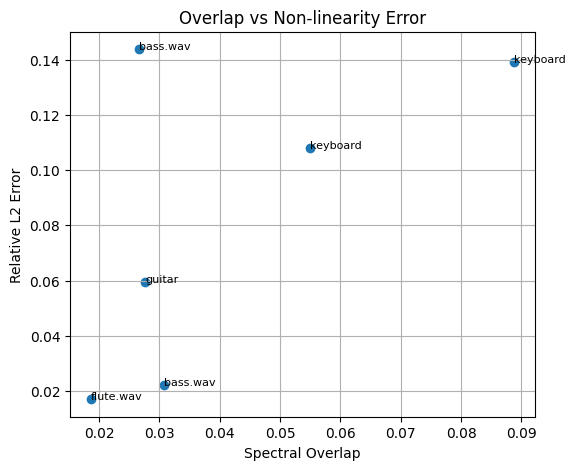

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.scatter(df["overlap"], df["relative_l2"])

for i, row in df.iterrows():
    plt.text(row["overlap"], row["relative_l2"], row["file_x"].split("_")[1], fontsize=8)

plt.xlabel("Spectral Overlap")
plt.ylabel("Relative L2 Error")
plt.title("Overlap vs Non-linearity Error")
plt.grid(True)
plt.show()

In [12]:
df.describe()

,l2,relative_l2,mae,overlap
count,5.000000,5.000000,5.000000,5.000000
mean,355.847229,0.094501,0.049838,0.045735
std,258.316742,0.052753,0.038929,0.026712
min,98.245613,0.021941,0.016000,0.026556
25%,169.174225,0.059320,0.029312,0.027602
50%,279.219238,0.108074,0.039424,0.030825
75%,506.381989,0.139273,0.048399,0.054945
max,726.214905,0.143900,0.116056,0.088750


In [ ]:
print("Mean relative L2:", df["relative_l2"].mean())
print("Std relative L2:", df["relative_l2"].std())

Mean relative L2: 0.09450132437050343
Std relative L2: 0.05275341103879107
